# 05 · Beijing PM2.5 — Forecasting the Extremes (quantiles & probabilistic warnings)

## Part 5 — Forecasting the Extremes (extending Part 4)

Part 4 left us with a sharp problem: the model **under-predicts the worst pollution** (actual >300:
~357 vs ~250 forecast, worsening with severity). For an air-quality *warning* system that's the
costliest failure — **missing an airpocalypse is far worse than a false alarm**. This notebook
extends the forecast to take the **tail** seriously:

1. *why* a standard (L2) model under-predicts extremes — and a tempting "fix" that makes it **worse**;
2. **quantile regression** — predicting the upper tail to track the spikes;
3. the **no-free-lunch tradeoff** (catching extremes costs average accuracy);
4. a principled, **probabilistic exceedance-warning** system tuned to the cost asymmetry.

The meta-lesson: **match the loss function to what you actually care about** — here, the dangerous
tail, not the average hour.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve
from src import forecasting as fc

g = pd.read_csv(data.DATA_PROC / "beijing_imputed.csv", parse_dates=["datetime"]).set_index("datetime")
g["pm25"] = g["pm25"].clip(lower=0)          # concentrations can't be negative (a MICE imputation artifact)
y = g["pm25"]
g["lag24"]=y.shift(24); g["lag168"]=y.shift(168); g["lag_dayavg"]=y.shift(24).rolling(24).mean()
g["hour"]=g.index.hour; g["month"]=g.index.month; g["dow"]=g.index.dayofweek; g["wdir"]=g["wind_dir"].astype("category").cat.codes
FEAT = ["lag24","lag168","lag_dayavg","TEMP","DEWP","PRES","Iws","Is","Ir","hour","month","dow","wdir"]
g = g.dropna(subset=["lag24","lag168","lag_dayavg"])
split = g.index.max() - pd.Timedelta(days=90); tr, te = g[g.index <= split], g[g.index > split]
real = (~te["pm25_was_imputed"]).to_numpy(); yt = te["pm25"].to_numpy()[real]
Xtr, Xte, ytr = tr[FEAT], te[FEAT], tr["pm25"]
P = dict(n_estimators=600, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
def gbm(**kw): return lgb.LGBMRegressor(**{**P, **kw})
print("train %d / test %d (real %.0f%%) | %% test hours hazardous (>150): %.0f%%" % (len(tr), len(te), 100*real.mean(), 100*(yt>150).mean()))

setup ok | numpy 2.1.3 | pandas 2.3.3


train 41496 / test 2160 (real 98%) | % test hours hazardous (>150): 28%


### 1. Why the mean under-predicts — and the log trap

A squared-error (L2) model predicts the **conditional mean**. Extreme pollution hours are rare, so
the mean for any given condition sits *well below* the spikes — the model literally can't justify a
700 µg/m³ forecast when most similar hours were 150. Hence the under-prediction.

A tempting fix is to **model `log(pm25)`** (it's right-skewed). It does the **opposite** of what we
want: `exp(mean of log)` is the **geometric mean / median**, which is *lower* than the arithmetic
mean — so it suppresses the peaks **even more**. A reminder to always check, not assume:

In [2]:
L2 = gbm().fit(Xtr, ytr).predict(Xte)
logm = np.expm1(gbm().fit(Xtr, np.log1p(ytr)).predict(Xte))
hi = yt > 300
for tag, p in [("L2 (mean)", L2), ("log-target", logm)]:
    p = np.clip(p, 0, None)[real]
    print("%-12s overall MAE %.1f | mean prediction on actual>300 hours: %.0f (truth 357)" % (tag, np.abs(p-yt).mean(), p[hi].mean()))
print("-> log-target LOWERS the extreme predictions — the wrong tool for the tail.")

L2 (mean)    overall MAE 45.2 | mean prediction on actual>300 hours: 257 (truth 357)
log-target   overall MAE 45.3 | mean prediction on actual>300 hours: 231 (truth 357)
-> log-target LOWERS the extreme predictions — the wrong tool for the tail.


### 2. Quantile regression — predicting the tail

Instead of the mean, train models for chosen **quantiles** (the pinball loss). The **median (q50)**
is a robust point forecast; the **upper quantiles (q90, q95)** deliberately track the *high* end —
they answer "how bad could it plausibly get?", which is exactly the warning question.

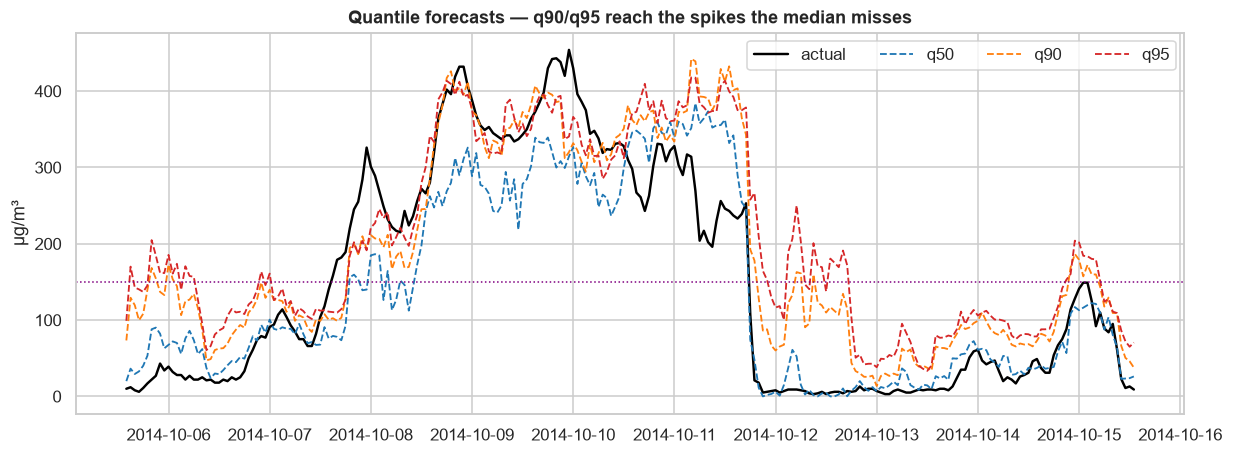

In [3]:
quants = {a: np.clip(gbm(objective="quantile", alpha=a).fit(Xtr, ytr).predict(Xte), 0, None) for a in [0.5, 0.9, 0.95]}
# show them on the highest-pollution stretch of the test
c = te["pm25"].rolling(48).mean().idxmax(); i = te.index.get_loc(c)
seg = slice(max(0, i-120), i+120); idx = te.index[seg]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(idx, te["pm25"].values[seg], color="black", lw=1.6, label="actual")
for a, c2 in [(0.5,"tab:blue"),(0.9,"tab:orange"),(0.95,"tab:red")]:
    ax.plot(idx, quants[a][seg], "--", color=c2, lw=1.2, label=f"q{int(a*100)}")
ax.axhline(150, color="purple", ls=":", lw=1)
ax.set_title("Quantile forecasts — q90/q95 reach the spikes the median misses"); ax.legend(ncol=4); ax.set_ylabel("µg/m³")
eda.savefig(fig, "p5_quantiles.png"); plt.show()

### 3. The tradeoff — no free lunch

Score each forecast as a point estimate (MAE), on the extremes (mean prediction where truth > 300),
and as a warning (recall of >150 hours). Climbing the quantiles **captures the tail and lifts recall
toward 1.0**, but **inflates MAE and slashes precision** — over-warning. The quantile level *is* your
risk appetite.

In [4]:
rows = []
for tag, p in [("L2 mean", L2), ("q50 median", quants[0.5]), ("q90", quants[0.9]), ("q95", quants[0.95]),
               ("tweedie", np.clip(gbm(objective="tweedie", tweedie_variance_power=1.5).fit(Xtr, ytr).predict(Xte), 0, None))]:
    p = np.clip(p, 0, None)[real]
    rows.append([tag, np.abs(p-yt).mean(), p[hi].mean(),
                 precision_score(yt>150, p>150), recall_score(yt>150, p>150), f1_score(yt>150, p>150)])
print(pd.DataFrame(rows, columns=["model","MAE","pred@>300","exc_P","exc_R","exc_F1"]).set_index("model").round(2).to_string())
print("\n-> q90/q95 nearly close the extreme gap (327/344 vs 357) and reach 0.93/0.98 recall — at a real cost.")
print("   tweedie barely moves the tail: a loss tweak alone doesn't solve it.")

              MAE  pred@>300  exc_P  exc_R  exc_F1
model                                             
L2 mean     45.18     256.56   0.78   0.75    0.76
q50 median  44.02     248.66   0.79   0.70    0.74
q90         64.42     327.06   0.56   0.93    0.70
q95         79.59     343.80   0.49   0.98    0.65
tweedie     44.63     242.71   0.79   0.69    0.74

-> q90/q95 nearly close the extreme gap (327/344 vs 357) and reach 0.93/0.98 recall — at a real cost.
   tweedie barely moves the tail: a loss tweak alone doesn't solve it.


### 4. The right tool for the warning — a probabilistic classifier

The cleanest way to *warn* isn't to threshold a point forecast at all — it's to model the
**probability** of exceedance directly, then choose the alarm threshold from the **cost asymmetry**.
For health, a missed hazard costs more than a false alarm, so we move the threshold **down** to buy
recall. The precision–recall curve makes that choice explicit.

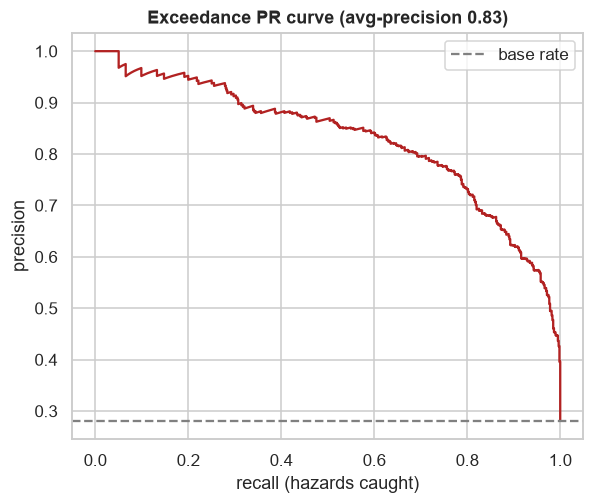

threshold choice (health prioritises recall):
  P>0.50  precision 0.79  recall 0.71  F1 0.75
  P>0.35  precision 0.75  recall 0.79  F1 0.77
  P>0.25  precision 0.69  recall 0.83  F1 0.75


In [5]:
clf = lgb.LGBMClassifier(**P).fit(Xtr, (ytr > 150).astype(int))
prob = clf.predict_proba(Xte)[:, 1][real]
ap = average_precision_score(yt > 150, prob)
prec, rec, thr = precision_recall_curve(yt > 150, prob)
fig, ax = plt.subplots(figsize=(6, 4.8))
ax.plot(rec, prec, color="firebrick"); ax.axhline((yt>150).mean(), color="grey", ls="--", label="base rate")
ax.set_xlabel("recall (hazards caught)"); ax.set_ylabel("precision"); ax.set_title(f"Exceedance PR curve (avg-precision {ap:.2f})"); ax.legend()
eda.savefig(fig, "p5_pr_curve.png"); plt.show()
print("threshold choice (health prioritises recall):")
for t in [0.5, 0.35, 0.25]:
    print("  P>%.2f  precision %.2f  recall %.2f  F1 %.2f" % (t, precision_score(yt>150,prob>t), recall_score(yt>150,prob>t), f1_score(yt>150,prob>t)))

### Takeaways

- **An L2 model predicts the mean, so it under-predicts rare extremes** — and modelling `log(pm25)`
  makes it *worse* (it targets the median). Don't assume a transform helps the tail; **measure it**.
- **Quantile regression captures the tail**: q90/q95 track the spikes (pred 327/344 vs truth 357) and
  catch **93–98%** of hazardous hours — but at higher MAE and lower precision. There is **no free
  lunch**; the quantile level encodes how much over-warning you'll tolerate.
- **The principled warning system is a probabilistic exceedance classifier** (avg-precision 0.83):
  output a calibrated probability and pick the alarm threshold from the **cost asymmetry** — lower it
  to prioritise recall when missing a hazard is the expensive error.
- **Match the loss to the goal**: minimise MAE for the *average* hour, but optimise quantiles / a
  classifier for the *dangerous tail*. They are different objectives and need different tools.

*This extends Part 4 into a tail-aware, decision-focused forecast — the natural endpoint of a
pollution study, where the extremes are the whole point.*